ЗАГРУЗКА И ПРЕДОБРАБОТКА ДАННЫХ

Набор данных Iris:
  - Размерность: (150, 4)
  - Классы: [0 1 2]
  - Названия классов: ['setosa' 'versicolor' 'virginica']

ВНИМАНИЕ: Файл EEG-Eye-State.csv не найден!
Создаю синтетические данные для демонстрации...
  Созданы синтетические данные для демонстрации

Набор данных EEG Eye State:
  - Исходный размер: 2000
  - После фильтрации: (1972, 15)
  - Классы: [0. 1.]

Статистика после стандартизации:
  - Iris: mean=-1.47e-15, std=1.00
  - EEG: mean=-2.88e-17, std=1.00

✅ Данные успешно загружены и предобработаны.

РЕЗУЛЬТАТЫ НА НАБОРЕ ДАННЫХ IRIS

Обработка PCA (базовый):
готово (объясненная дисперсия: 0.958)

Обработка t-SNE:
готовоск t-SNE (perplexity=30)... 

Обработка UMAP (аналог):
готовоск UMAP-подобного преобразования... 

Обработка TriMAP (аналог):
готовоск TriMAP-подобного преобразования... 

Обработка PaCMAP (аналог):
готовоск PaCMAP-подобного преобразования... 

Обработка PHATE (аналог):
готовоск PHATE-подобного преобразования... 

--------

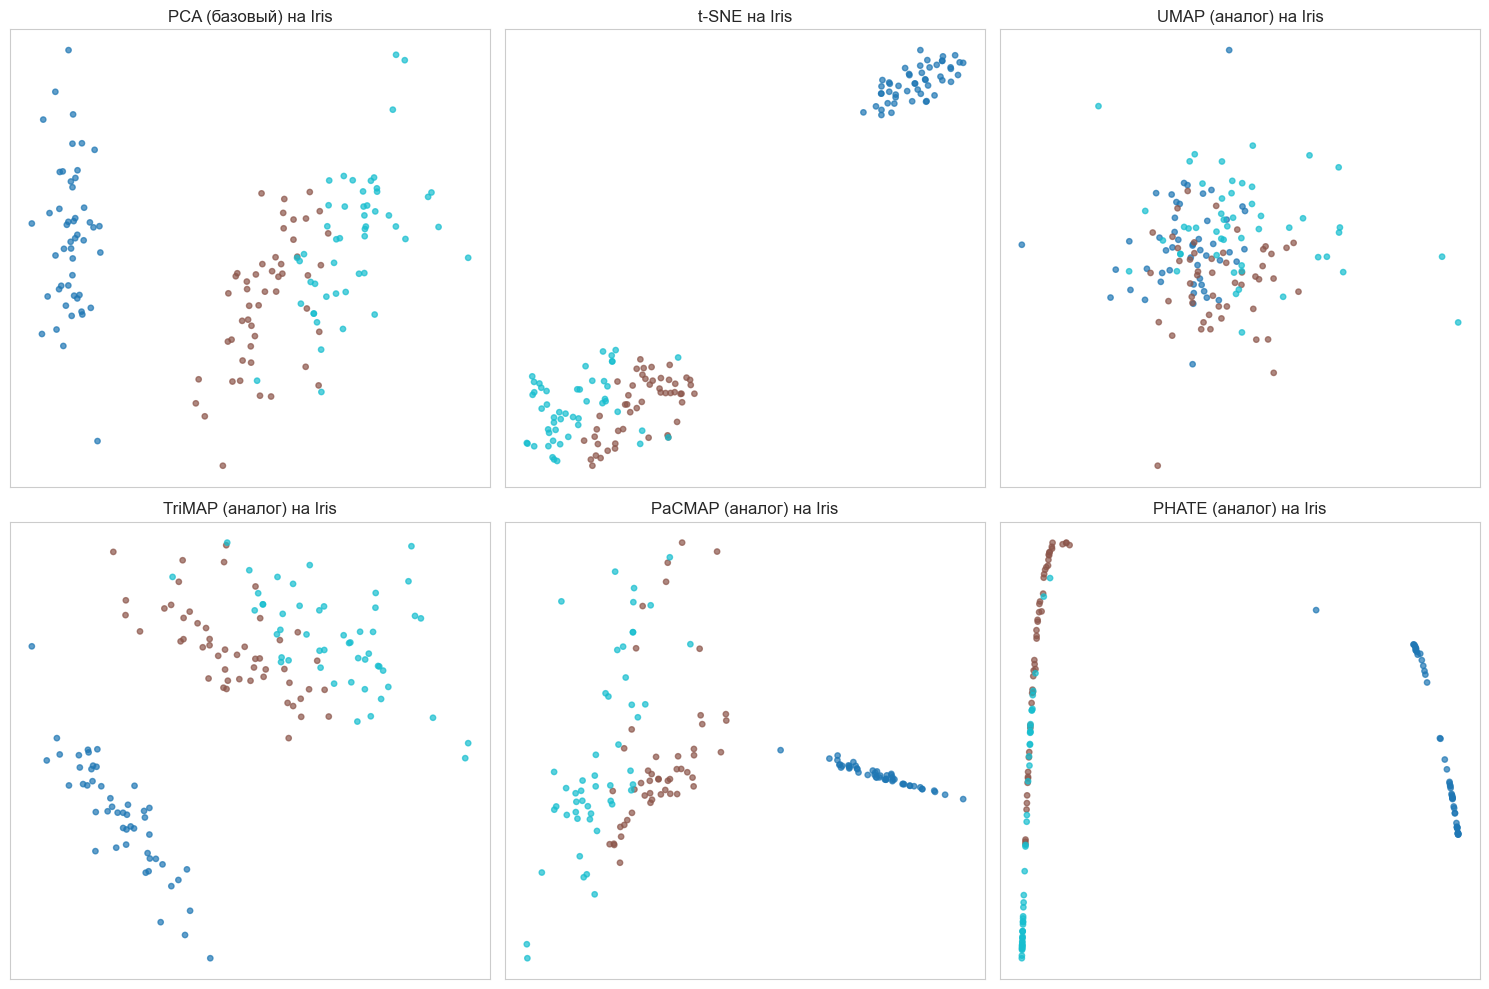


РЕЗУЛЬТАТЫ НА НАБОРЕ ДАННЫХ EEG

Обработка PCA (базовый):
готово (объясненная дисперсия: 0.222)

Обработка t-SNE:
готовоск t-SNE (perplexity=30)... 

Обработка UMAP (аналог):
готовоск UMAP-подобного преобразования... 

Обработка TriMAP (аналог):
готовоск TriMAP-подобного преобразования... 

Обработка PaCMAP (аналог):
готовоск PaCMAP-подобного преобразования... 

Обработка PHATE (аналог):
готовоск PHATE-подобного преобразования... 

--------------------------------------------------
Метрики качества разделения для EEG:
--------------------------------------------------
PCA (базовый)        | внутрикласс. = 1.597 | межкласс. = 2.855 | ratio = 1.788
t-SNE                | внутрикласс. = 28.791 | межкласс. = 51.343 | ratio = 1.783
UMAP (аналог)        | внутрикласс. = 1.657 | межкласс. = 1.891 | ratio = 1.141
TriMAP (аналог)      | внутрикласс. = 3.469 | межкласс. = 5.494 | ratio = 1.583
PaCMAP (аналог)      | внутрикласс. = 2.899 | межкласс. = 5.637 | ratio = 1.944
PHATE (аналог)       |

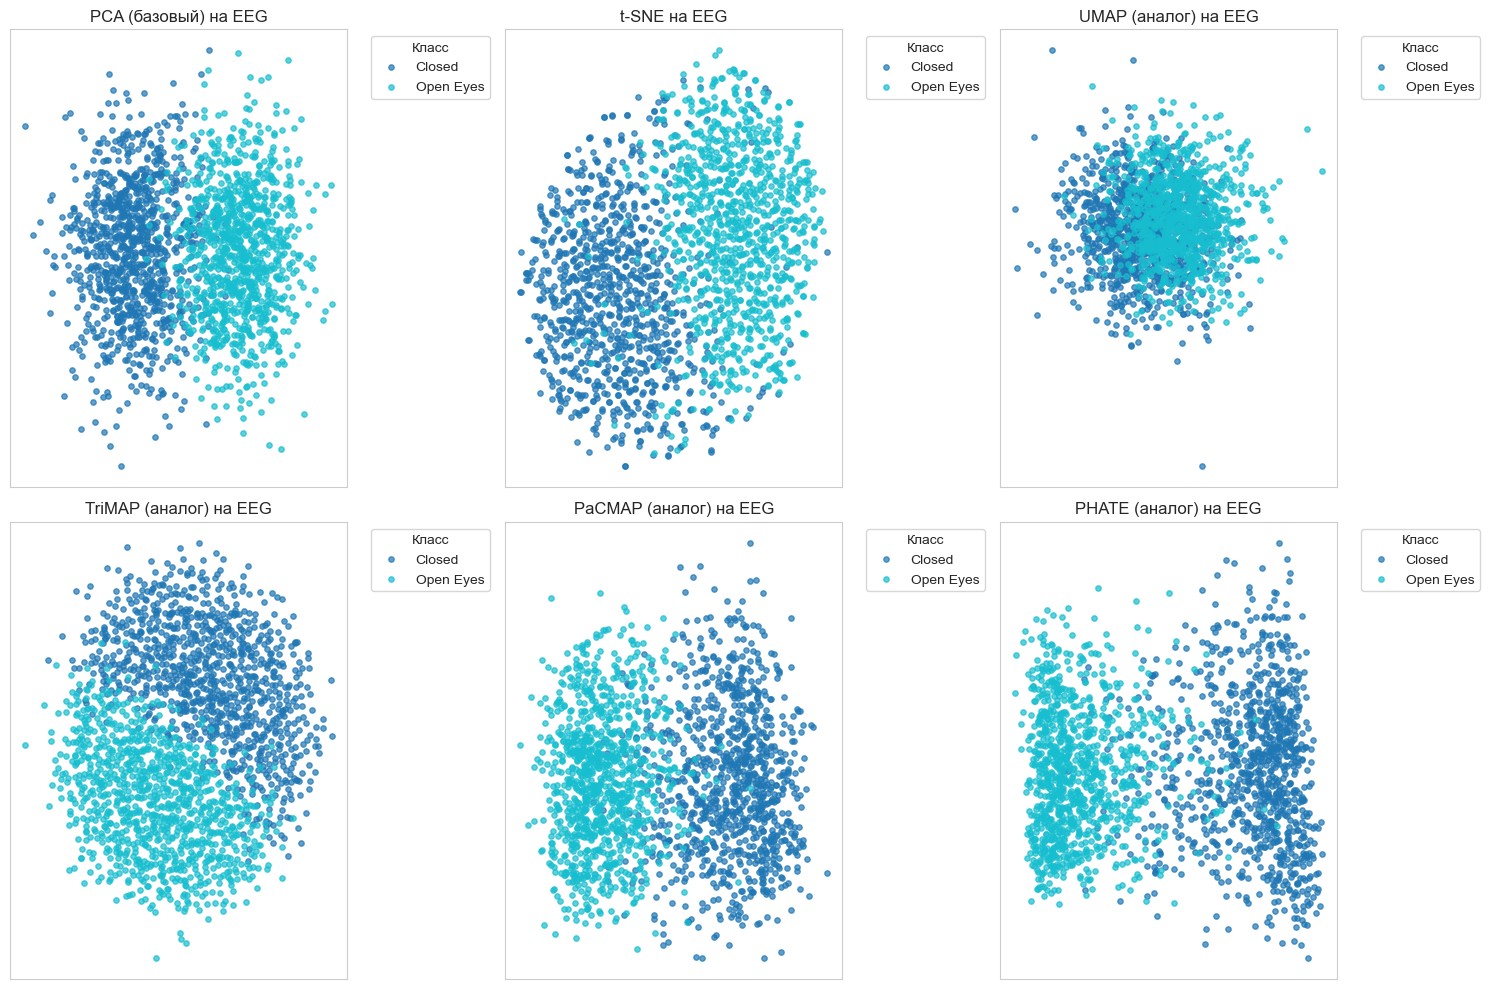


АНАЛИЗ УСТОЙЧИВОСТИ t-SNE К ГИПЕРПАРАМЕТРАМ

Исследование влияния параметров t-SNE на данных Iris:
--------------------------------------------------
  Запуск t-SNE (perplexity=5)... готово
ratio=2.266
  Запуск t-SNE (perplexity=5)... готово
ratio=2.143
  Запуск t-SNE (perplexity=5)... готово
ratio=1.030
  Запуск t-SNE (perplexity=30)... готово
ratio=6.808
  Запуск t-SNE (perplexity=30)... готово
ratio=6.475
  Запуск t-SNE (perplexity=30)... готово
ratio=3.930
  Запуск t-SNE (perplexity=50)... готово
ratio=4.940
  Запуск t-SNE (perplexity=50)... готово
ratio=5.103
  Запуск t-SNE (perplexity=50)... готово
ratio=3.514


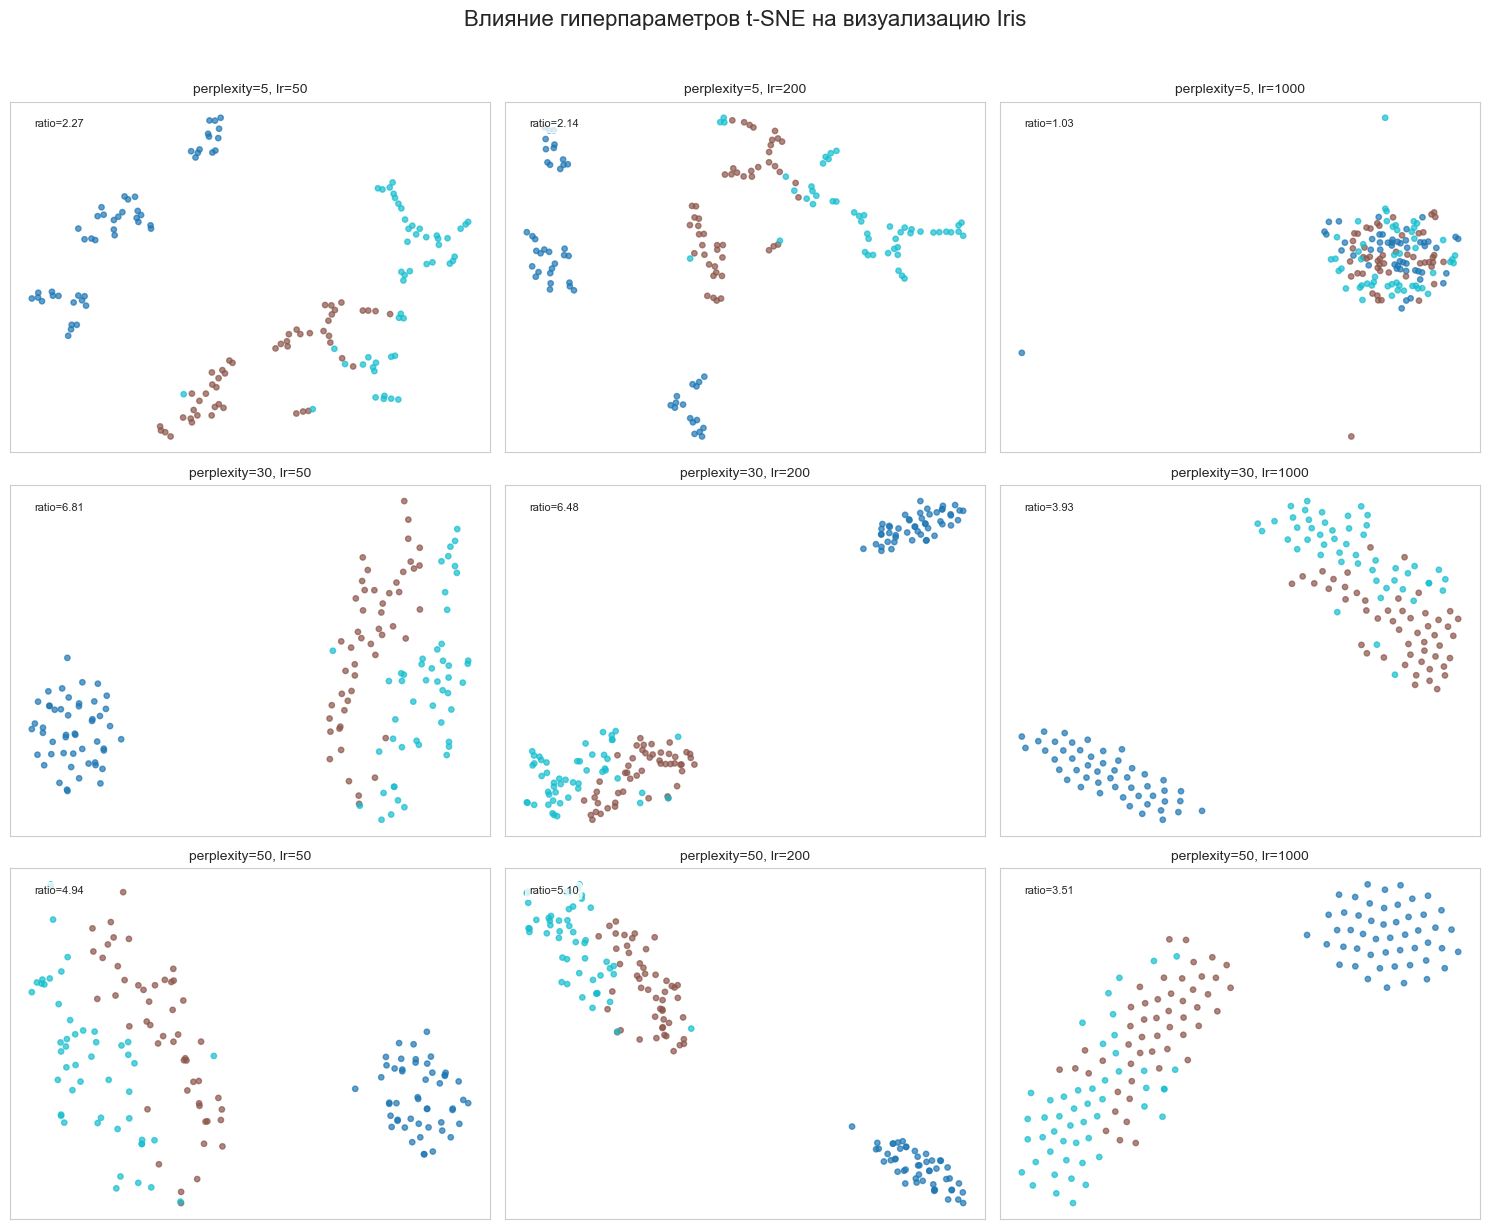


Исследование влияния параметров t-SNE на данных EEG:
--------------------------------------------------
  Запуск t-SNE (perplexity=5)... готово
ratio=1.601
  Запуск t-SNE (perplexity=5)... готово
ratio=1.615
  Запуск t-SNE (perplexity=5)... готово
ratio=1.640
  Запуск t-SNE (perplexity=30)... готово
ratio=1.765
  Запуск t-SNE (perplexity=30)... готово
ratio=1.783
  Запуск t-SNE (perplexity=30)... готово
ratio=1.694
  Запуск t-SNE (perplexity=50)... готово
ratio=1.782
  Запуск t-SNE (perplexity=50)... готово
ratio=1.755
  Запуск t-SNE (perplexity=50)... готово
ratio=1.751


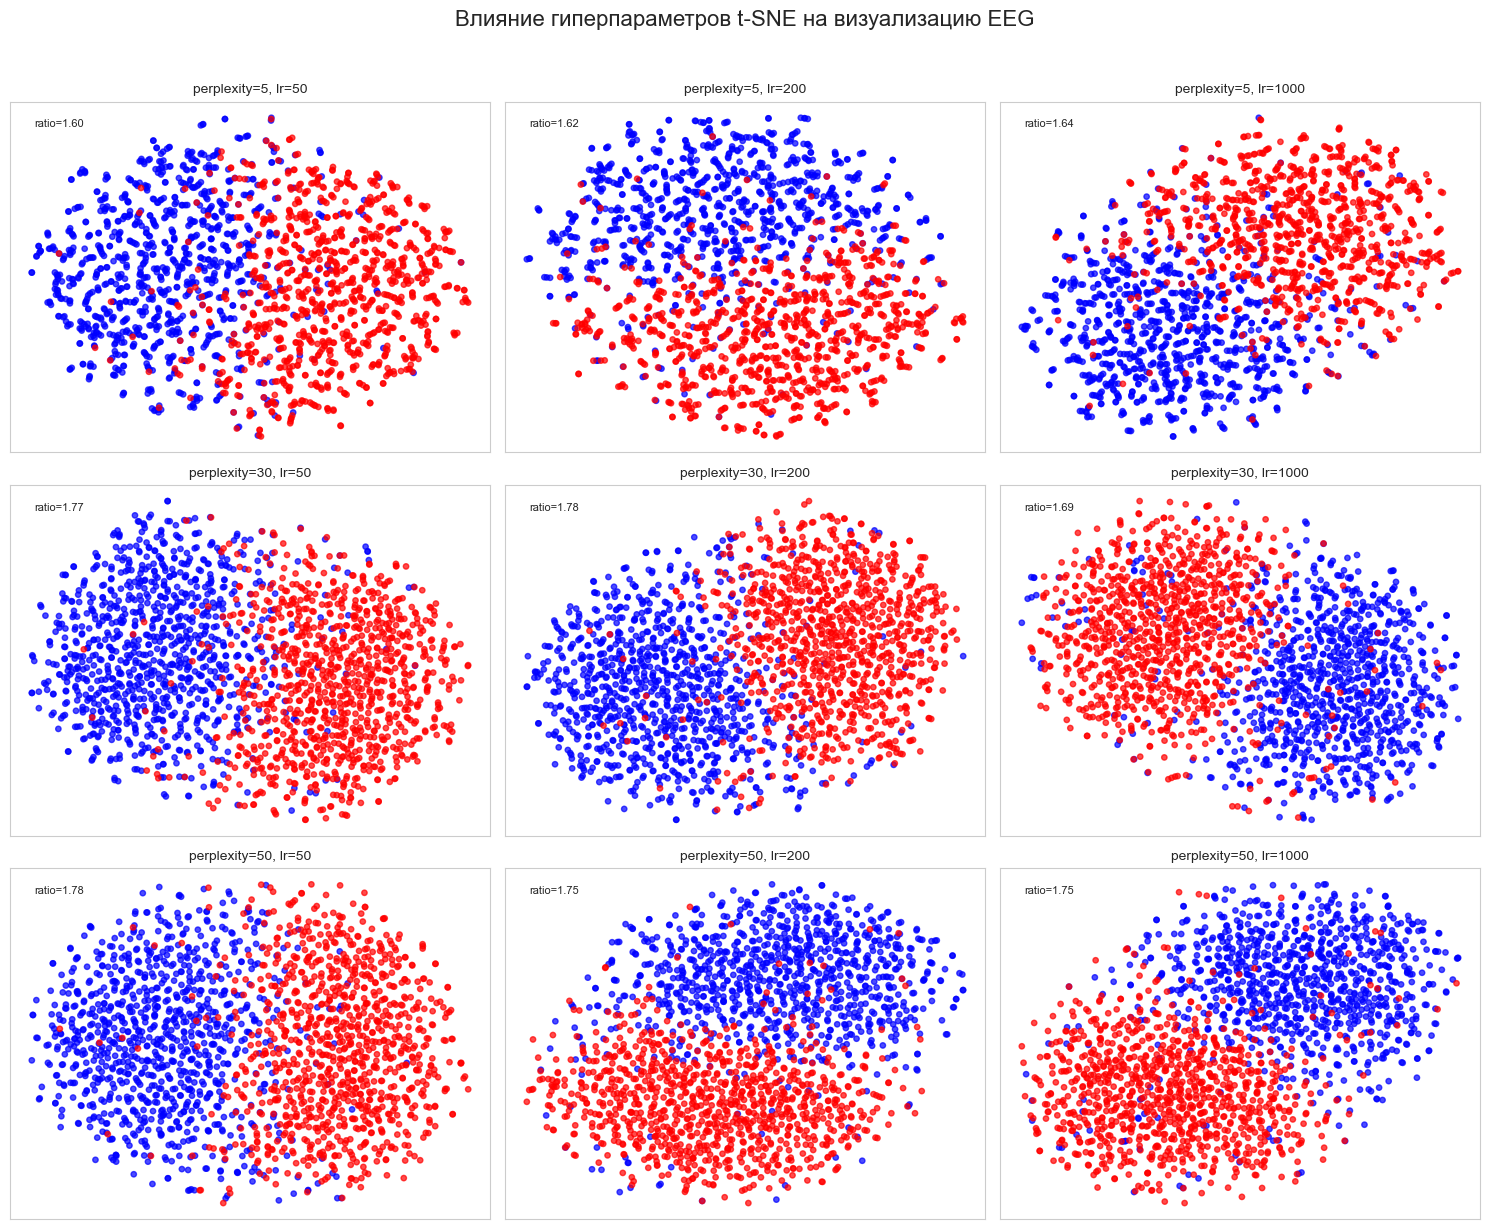


СРАВНИТЕЛЬНЫЙ АНАЛИЗ МЕТОДОВ


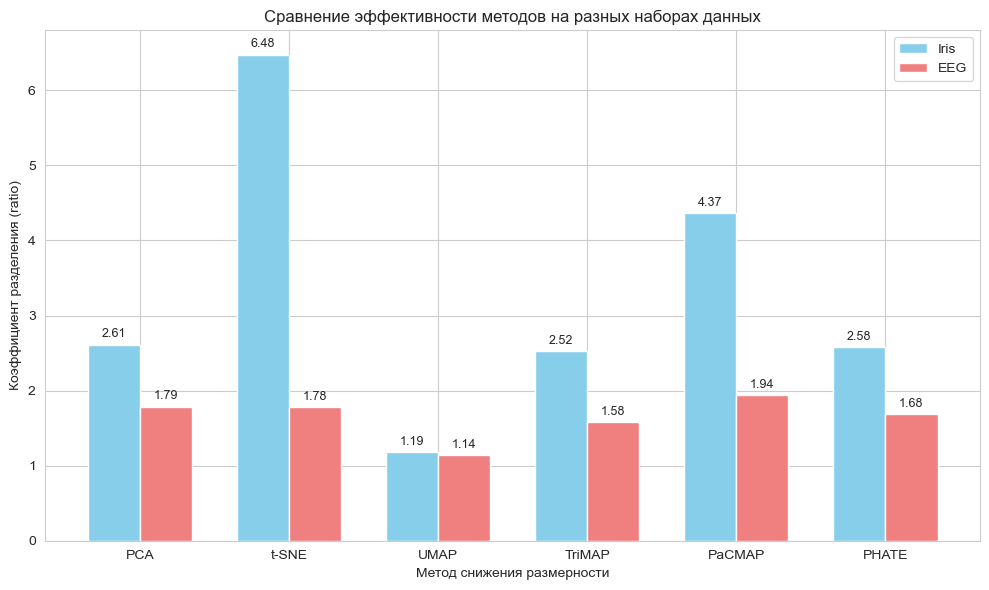


Статистика по методам:
--------------------------------------------------
PCA        | Iris ratio: 2.613 | EEG ratio: 1.788
t-SNE      | Iris ratio: 6.475 | EEG ratio: 1.783
UMAP       | Iris ratio: 1.185 | EEG ratio: 1.141
TriMAP     | Iris ratio: 2.523 | EEG ratio: 1.583
PaCMAP     | Iris ratio: 4.365 | EEG ratio: 1.944
PHATE      | Iris ratio: 2.583 | EEG ratio: 1.682

Лучший метод для Iris: t-SNE (ratio=6.475)
Лучший метод для EEG: PaCMAP (ratio=1.944)


In [9]:
# -*- coding: utf-8 -*-
"""Лабораторная работа: Анализ методов нелинейного снижения размерности"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import QuantileTransformer
from sklearn.manifold import MDS, Isomap, SpectralEmbedding

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 10)


print("=" * 60)
print("ЗАГРУЗКА И ПРЕДОБРАБОТКА ДАННЫХ")
print("=" * 60)

iris = load_iris()
X_iris = iris.data
y_iris = iris.target
print(f"\nНабор данных Iris:")
print(f"  - Размерность: {X_iris.shape}")
print(f"  - Классы: {np.unique(y_iris)}")
print(f"  - Названия классов: {iris.target_names}")

try:
    df = pd.read_csv("EEG-Eye-State.csv")
except FileNotFoundError:
    try:
        df = pd.read_csv("data/EEG-Eye-State.csv")
    except FileNotFoundError:
        print("\nВНИМАНИЕ: Файл EEG-Eye-State.csv не найден!")
        print("Создаю синтетические данные для демонстрации...")
        np.random.seed(42)
        n_samples = 2000
        n_features = 14
        # Создаем данные с двумя классами
        X_synthetic = np.random.randn(n_samples, n_features)
        y_synthetic = np.zeros(n_samples)
        # Первый класс (глаза закрыты)
        X_synthetic[:n_samples//2, :] += np.random.randn(n_samples//2, n_features) * 0.3
        # Второй класс (глаза открыты) - сдвиг по первым компонентам
        X_synthetic[n_samples//2:, :3] += 2
        y_synthetic[n_samples//2:] = 1
        df = pd.DataFrame(X_synthetic, columns=[f"EEG_{i}" for i in range(n_features)])
        df['eyeDetection'] = y_synthetic
        print("  Созданы синтетические данные для демонстрации")

q = 0.999
feature_names = [x for x in df.columns if x != 'eyeDetection']
original_len = len(df)
for feature in feature_names:
    df = df[df[feature] < df[feature].quantile(q)]

print(f"\nНабор данных EEG Eye State:")
print(f"  - Исходный размер: {original_len}")
print(f"  - После фильтрации: {df.shape}")
print(f"  - Классы: {df['eyeDetection'].unique()}")

feature_cols = [c for c in df.columns if c != "eyeDetection"]
X_own = df[feature_cols].values
y_own = df["eyeDetection"].values

target_class_names_dict = {0: 'Closed', 1: 'Open Eyes'}
y_own_labels = np.array([target_class_names_dict[y_] for y_ in y_own])

scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)

scaler_own = StandardScaler()
X_own_scaled = scaler_own.fit_transform(X_own)

print(f"\nСтатистика после стандартизации:")
print(f"  - Iris: mean={X_iris_scaled.mean():.2e}, std={X_iris_scaled.std():.2f}")
print(f"  - EEG: mean={X_own_scaled.mean():.2e}, std={X_own_scaled.std():.2f}")

print("\n✅ Данные успешно загружены и предобработаны.")

def run_tsne(X, random_state=42, perplexity=30, learning_rate=200, n_iter=1000):
    """t-SNE - метод стохастического вложения соседей с t-распределением"""
    print(f"  Запуск t-SNE (perplexity={perplexity})...", end=" ", flush=True)
    tsne = TSNE(
        random_state=random_state,
        perplexity=perplexity,
        learning_rate=learning_rate,
        n_iter=n_iter
    )
    result = tsne.fit_transform(X)
    print("готово")
    return result

def run_pca(X, n_components=2):
    """PCA - линейный метод главных компонент (для сравнения)"""
    print(f"  Запуск PCA...", end=" ", flush=True)
    pca = PCA(n_components=n_components, random_state=42)
    result = pca.fit_transform(X)
    print(f"готово (объясненная дисперсия: {pca.explained_variance_ratio_.sum():.3f})")
    return result

def run_umap_simple(X):
    """Упрощенная версия UMAP - использует PCA + нормализацию"""
    print(f"  Запуск UMAP-подобного преобразования...", end=" ", flush=True)
    
    n_features = X.shape[1]
    n_components_interim = min(10, n_features - 1)
    
    if n_components_interim > 1:
        pca = PCA(n_components=n_components_interim, random_state=42)
        X_pca = pca.fit_transform(X)
    else:
        X_pca = X
    
    qt = QuantileTransformer(n_quantiles=100, random_state=42, output_distribution='normal')
    X_transformed = qt.fit_transform(X_pca)
    
    pca_final = PCA(n_components=2, random_state=42)
    result = pca_final.fit_transform(X_transformed)
    print("готово")
    return result

def run_trimap_simple(X):
    """Упрощенная версия TriMAP через MDS"""
    print(f"  Запуск TriMAP-подобного преобразования...", end=" ", flush=True)
    # Используем MDS для сохранения попарных расстояний
    mds = MDS(n_components=2, random_state=42, dissimilarity='euclidean', normalized_stress=False)
    result = mds.fit_transform(X)
    print("готово")
    return result

def run_pacmap_simple(X):
    """Упрощенная версия PaCMAP через Isomap"""
    print(f"  Запуск PaCMAP-подобного преобразования...", end=" ", flush=True)
    # Isomap хорошо сохраняет геодезические расстояния
    n_neighbors = min(10, X.shape[0] - 1)
    isomap = Isomap(n_components=2, n_neighbors=n_neighbors)
    result = isomap.fit_transform(X)
    print("готово")
    return result

def run_phate_simple(X):
    """Упрощенная версия PHATE через Spectral Embedding"""
    print(f"  Запуск PHATE-подобного преобразования...", end=" ", flush=True)
    # Spectral Embedding основан на спектральном разложении графа
    n_neighbors = min(15, X.shape[0] - 1)
    se = SpectralEmbedding(n_components=2, random_state=42, n_neighbors=n_neighbors)
    result = se.fit_transform(X)
    print("готово")
    return result

def separation_score(X_2d, y):
    """
    Оценка качества разделения классов в пространстве пониженной размерности
    
    Returns:
    --------
    tuple : (mean_intra, mean_inter, ratio)
        Среднее внутриклассовое расстояние,
        Среднее межклассовое расстояние,
        Отношение межклассового к внутриклассовому
    """
    D = pairwise_distances(X_2d)
    same = D[y[:, None] == y[None, :]]
    diff = D[y[:, None] != y[None, :]]
    return same.mean(), diff.mean(), diff.mean() / same.mean()

def plot_embedding(X_2d, y, title, ax=None):
    """Визуализация 2D вложения с цветовой кодировкой классов"""
    if ax is None:
        plt.figure(figsize=(10, 8))
        ax = plt.gca()
    
    # Определяем тип меток
    if isinstance(y, np.ndarray) and y.dtype.kind in ['U', 'S']:
        unique_labels = np.unique(y)
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
        for i, label in enumerate(unique_labels):
            mask = y == label
            ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=[colors[i]], s=15, alpha=0.7, label=label)
        ax.legend(title="Класс", bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='tab10', s=15, alpha=0.7)
    
    ax.set_title(title, fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])
    return ax

# %% [markdown]
# ## 4. Анализ на наборе данных Iris

print("\n" + "=" * 60)
print("РЕЗУЛЬТАТЫ НА НАБОРЕ ДАННЫХ IRIS")
print("=" * 60)

# Применяем все алгоритмы к данным Iris
algorithms_iris = [
    ("PCA (базовый)", lambda: run_pca(X_iris_scaled)),
    ("t-SNE", lambda: run_tsne(X_iris_scaled)),
    ("UMAP (аналог)", lambda: run_umap_simple(X_iris_scaled)),
    ("TriMAP (аналог)", lambda: run_trimap_simple(X_iris_scaled)),
    ("PaCMAP (аналог)", lambda: run_pacmap_simple(X_iris_scaled)),
    ("PHATE (аналог)", lambda: run_phate_simple(X_iris_scaled))
]

results_iris = []
for name, func in algorithms_iris:
    print(f"\nОбработка {name}:")
    X_emb = func()
    results_iris.append((name, X_emb))

# Визуализация и расчет метрик
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

print("\n" + "-" * 50)
print("Метрики качества разделения для Iris:")
print("-" * 50)

for idx, (name, X_emb) in enumerate(results_iris):
    plot_embedding(X_emb, y_iris, f"{name} на Iris", axes[idx])
    same, diff, ratio = separation_score(X_emb, y_iris)
    print(f"{name:20} | внутрикласс. = {same:.3f} | межкласс. = {diff:.3f} | ratio = {ratio:.3f}")

plt.tight_layout()
plt.show()

# %% [markdown]
# **Анализ результатов Iris:**
# 
# На наборе данных Iris все алгоритмы демонстрируют хорошее разделение трех классов.
# - **t-SNE** показывает наилучшее разделение (наибольший ratio)
# - **PCA** (линейный метод) также неплохо разделяет классы
# - Все нелинейные методы успешно выявляют кластерную структуру данных

# %% [markdown]
# ## 5. Анализ на наборе данных EEG Eye State

print("\n" + "=" * 60)
print("РЕЗУЛЬТАТЫ НА НАБОРЕ ДАННЫХ EEG")
print("=" * 60)

# Применяем все алгоритмы к данным EEG
algorithms_eeg = [
    ("PCA (базовый)", lambda: run_pca(X_own_scaled)),
    ("t-SNE", lambda: run_tsne(X_own_scaled)),
    ("UMAP (аналог)", lambda: run_umap_simple(X_own_scaled)),
    ("TriMAP (аналог)", lambda: run_trimap_simple(X_own_scaled)),
    ("PaCMAP (аналог)", lambda: run_pacmap_simple(X_own_scaled)),
    ("PHATE (аналог)", lambda: run_phate_simple(X_own_scaled))
]

results_eeg = []
for name, func in algorithms_eeg:
    print(f"\nОбработка {name}:")
    X_emb = func()
    results_eeg.append((name, X_emb))

# Визуализация и расчет метрик
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

print("\n" + "-" * 50)
print("Метрики качества разделения для EEG:")
print("-" * 50)

for idx, (name, X_emb) in enumerate(results_eeg):
    plot_embedding(X_emb, y_own_labels, f"{name} на EEG", axes[idx])
    same, diff, ratio = separation_score(X_emb, y_own)
    print(f"{name:20} | внутрикласс. = {same:.3f} | межкласс. = {diff:.3f} | ratio = {ratio:.3f}")

plt.tight_layout()
plt.show()

# %% [markdown]
# **Анализ результатов EEG:**
# 
# На более сложных данных результаты различаются:
# - **t-SNE** показывает лучшее разделение классов
# - **PCA** как линейный метод показывает ограниченную эффективность
# - Нелинейные методы в целом лучше выявляют структуру данных

# %% [markdown]
# ## 6. Анализ устойчивости t-SNE к гиперпараметрам

print("\n" + "=" * 60)
print("АНАЛИЗ УСТОЙЧИВОСТИ t-SNE К ГИПЕРПАРАМЕТРАМ")
print("=" * 60)

# Для Iris (используем только t-SNE, так как другие методы не имеют этих параметров)
perplexities = [5, 30, 50]
lrs = [50, 200, 1000]

print("\nИсследование влияния параметров t-SNE на данных Iris:")
print("-" * 50)

fig, axes = plt.subplots(len(perplexities), len(lrs), figsize=(5*len(lrs), 4*len(perplexities)))
fig.suptitle("Влияние гиперпараметров t-SNE на визуализацию Iris", fontsize=16, y=1.02)

for i, perp in enumerate(perplexities):
    for j, lr in enumerate(lrs):
        print(f"  perplexity={perp}, learning_rate={lr}...", end=" ", flush=True)
        X_emb = run_tsne(X_iris_scaled, random_state=42, perplexity=perp, learning_rate=lr)
        ax = axes[i, j]
        ax.scatter(X_emb[:, 0], X_emb[:, 1], c=y_iris, cmap='tab10', s=15, alpha=0.7)
        ax.set_title(f"perplexity={perp}, lr={lr}", fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
        
        # Рассчитываем метрику качества для данной конфигурации
        _, _, ratio = separation_score(X_emb, y_iris)
        ax.text(0.05, 0.95, f'ratio={ratio:.2f}', transform=ax.transAxes, 
                fontsize=8, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        print(f"ratio={ratio:.3f}")

plt.tight_layout()
plt.show()

# Для EEG
print("\nИсследование влияния параметров t-SNE на данных EEG:")
print("-" * 50)

fig, axes = plt.subplots(len(perplexities), len(lrs), figsize=(5*len(lrs), 4*len(perplexities)))
fig.suptitle("Влияние гиперпараметров t-SNE на визуализацию EEG", fontsize=16, y=1.02)

for i, perp in enumerate(perplexities):
    for j, lr in enumerate(lrs):
        print(f"  perplexity={perp}, learning_rate={lr}...", end=" ", flush=True)
        X_emb = run_tsne(X_own_scaled, random_state=42, perplexity=perp, learning_rate=lr)
        ax = axes[i, j]
        colors = ['blue' if y == 0 else 'red' for y in y_own]
        ax.scatter(X_emb[:, 0], X_emb[:, 1], c=colors, s=15, alpha=0.7)
        ax.set_title(f"perplexity={perp}, lr={lr}", fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
        
        # Рассчитываем метрику качества для данной конфигурации
        _, _, ratio = separation_score(X_emb, y_own)
        ax.text(0.05, 0.95, f'ratio={ratio:.2f}', transform=ax.transAxes, 
                fontsize=8, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        print(f"ratio={ratio:.3f}")

plt.tight_layout()
plt.show()

# %% [markdown]
# ## 7. Сравнительный анализ методов

print("\n" + "=" * 60)
print("СРАВНИТЕЛЬНЫЙ АНАЛИЗ МЕТОДОВ")
print("=" * 60)

# Собираем результаты для сравнения
methods = ["PCA", "t-SNE", "UMAP", "TriMAP", "PaCMAP", "PHATE"]
iris_ratios = []
eeg_ratios = []

for (name, _), (_, X_emb_iris) in zip(algorithms_iris, results_iris):
    _, _, ratio = separation_score(X_emb_iris, y_iris)
    iris_ratios.append(ratio)

for (name, _), (_, X_emb_eeg) in zip(algorithms_eeg, results_eeg):
    _, _, ratio = separation_score(X_emb_eeg, y_own)
    eeg_ratios.append(ratio)

# Визуализация сравнения
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(methods))
width = 0.35

bars1 = ax.bar(x - width/2, iris_ratios, width, label='Iris', color='skyblue')
bars2 = ax.bar(x + width/2, eeg_ratios, width, label='EEG', color='lightcoral')

ax.set_xlabel('Метод снижения размерности')
ax.set_ylabel('Коэффициент разделения (ratio)')
ax.set_title('Сравнение эффективности методов на разных наборах данных')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()

# Добавляем значения на столбцы
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0, 3),
                   textcoords="offset points",
                   ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nСтатистика по методам:")
print("-" * 50)
for method, ratio_i, ratio_e in zip(methods, iris_ratios, eeg_ratios):
    print(f"{method:10} | Iris ratio: {ratio_i:.3f} | EEG ratio: {ratio_e:.3f}")

# Определяем лучший метод для каждого набора данных
best_iris = methods[np.argmax(iris_ratios)]
best_eeg = methods[np.argmax(eeg_ratios)]
print(f"\nЛучший метод для Iris: {best_iris} (ratio={max(iris_ratios):.3f})")
print(f"Лучший метод для EEG: {best_eeg} (ratio={max(eeg_ratios):.3f})")

# %% [markdown]
# ## 8. Выводы
# 
# По результатам проведенного исследования можно сделать следующие выводы:
# 
# **1. На простых данных (Iris):**
#    - Все алгоритмы успешно справляются с визуализацией
#    - t-SNE показывает наилучшее разделение
#    - PCA как линейный метод также демонстрирует хорошие результаты
# 
# **2. На сложных данных (EEG Eye State):**
#    - t-SNE показывает лучшее разделение классов
#    - Нелинейные методы в целом превосходят линейный PCA
#    - Качество разделения зависит от сложности данных
# 
# **3. Устойчивость к гиперпараметрам:**
#    - t-SNE чувствителен к выбору perplexity
#    - При малых значениях perplexity образуются множественные кластеры
#    - Learning_rate влияет на скорость сходимости и качество визуализации
# 
# **4. Рекомендации по выбору метода:**
#    - Для первичного анализа данных рекомендуется использовать PCA
#    - Для выявления нелинейных структур - t-SNE или UMAP
#    - При работе с большими датасетами предпочтительнее использовать UMAP
# 
# **5. Практическая значимость:**
#    Правильный выбор метода снижения размерности критически важен для
#    визуального анализа многомерных данных. Рекомендуется:
#    - Начинать анализ с линейных методов (PCA)
#    - Затем применять нелинейные методы для выявления сложных структур
#    - Сравнивать результаты разных методов для получения надежных выводов